In [8]:
from collections import defaultdict
from dataclasses import dataclass
import logging
from pathlib import Path
import re
from typing import Dict, List, Optional, Tuple
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

In [9]:
# ==============================================================================
# 1. LOGGING & WARNINGS SETUP
# ==============================================================================
warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("FishCountingEval")


# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
@dataclass(frozen=True)
class EvalConfig:
    """Central configuration for paths and model inference parameters."""

    gt_labels_dir: Path = Path("../gt_labels_new_tofill")
    recordings_dir: Path = Path("../recordings_counted")
    model_path: Path = Path("./runs/segment/train-19/weights/best.pt")
    output_dir: Path = Path("./evaluation_yolocount_vs_gtcount_output")

    # Inference parameters
    conf_threshold: float = 0.25
    iou_threshold: float = 0.45
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CONFIG = EvalConfig()
#CONFIG.output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"Using device: {CONFIG.device}")
logger.info(f"Output directory initialized: {CONFIG.output_dir.resolve()}")

[22:09:50] [INFO] Using device: cuda
[22:09:50] [INFO] Output directory initialized: /mnt/c/Users/sinke/Desktop/Masterarbeit/yolo/evaluation_yolocount_vs_gtcount_output


In [10]:
# ==============================================================================
# 3. HELPER FUNCTIONS
# ==============================================================================
def load_crop_box(
    finished_folder: Path,
    video_prefix: str,
    frame_nr: int,
    task_id: int,
    img_shape: Tuple[int, int, int],
) -> Tuple[int, int, int, int]:
    """Loads tank crop coordinates from the associated cut.txt file.

    Prevents counting fish in neighboring tanks.

    Args:
        finished_folder (Path): Directory containing finished GT masks and cut
          files.
        video_prefix (str): Identifier of the video (e.g. 'fishvideo1').
        frame_nr (int): Original frame number in the recording.
        task_id (int): Annotation task ID.
        img_shape (Tuple[int, int, int]): Shape (H, W, C) of the source image.

    Returns:
        Tuple[int, int, int, int]: Bounding box coordinates (x1, y1, x2, y2).
    """
    h_orig, w_orig = img_shape[:2]
    candidates = [
        finished_folder / f"{video_prefix}_{frame_nr:04d}_cut.txt",
        finished_folder / f"{video_prefix}_{frame_nr}_cut.txt",
        finished_folder / f"{video_prefix}_task-{task_id}_cut.txt",
        finished_folder / f"task-{task_id}_cut.txt",
    ]

    for cand in candidates:
        if cand.exists():
            with open(cand, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#"):
                        parts = [int(x.strip()) for x in line.split(",")]
                        if len(parts) == 4:
                            x1 = max(0, min(w_orig, parts[0]))
                            y1 = max(0, min(h_orig, parts[1]))
                            x2 = max(0, min(w_orig, parts[2]))
                            y2 = max(0, min(h_orig, parts[3]))
                            if x2 > x1 and y2 > y1:
                                return x1, y1, x2, y2

    logger.warning(
        f"No crop box found for {video_prefix} (Frame {frame_nr:04d}, Task-{task_id}). Using full frame."
    )
    return 0, 0, w_orig, h_orig


def load_cropped_mask(
    mask_path: Path,
    crop_coords: Tuple[int, int, int, int],
    orig_shape: Tuple[int, int],
) -> Optional[np.ndarray]:
    """Loads a single .npy / .npz binary mask, resizes if needed, and applies crop.

    Args:
        mask_path (Path): File path to mask.
        crop_coords (Tuple[int, int, int, int]): (x1, y1, x2, y2) bounds.
        orig_shape (Tuple[int, int]): (Height, Width) of the original image.

    Returns:
        Optional[np.ndarray]: Cropped binary mask (uint8) or None if empty.
    """
    x1, y1, x2, y2 = crop_coords
    h_orig, w_orig = orig_shape

    data = np.load(mask_path)
    mask = (
        data[list(data.keys())[0]] if mask_path.suffix == ".npz" else data
    ).astype(np.uint8)

    if mask.ndim == 3:
        mask = mask.squeeze()

    if mask.shape[:2] != (h_orig, w_orig):
        mask = cv2.resize(
            mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST
        )

    cropped = (mask[y1:y2, x1:x2] > 0).astype(np.uint8)
    return cropped if cropped.sum() > 0 else None


def categorize_mask_files(
    mask_files: List[Path],
) -> Dict[int, Dict[str, List[Path]]]:
    """Groups ground truth mask files by task_id and label category.

    Args:
        mask_files (List[Path]): List of filepaths to .npy/.npz mask files.

    Returns:
        Dict[int, Dict[str, List[Path]]]: Mapping of task_id -> {category: [paths]}.
    """
    task_groups = defaultdict(lambda: defaultdict(list))

    for mf in mask_files:
        match = re.search(r"task-(\d+)", mf.name)
        if not match:
            continue

        task_id = int(match.group(1))
        name_lower = mf.name.lower()

        if (
            "tag-fisch" in name_lower
            or "tag-fish-" in name_lower
            or "tag-fish." in name_lower
            or name_lower.endswith("-fish.npy")
        ):
            task_groups[task_id]["fish"].append(mf)
        elif "tag-snail" in name_lower:
            task_groups[task_id]["snail"].append(mf)
        elif "tag-fishneighbour" in name_lower:
            task_groups[task_id]["neighbour"].append(mf)
        elif "tag-reflection" in name_lower:
            task_groups[task_id]["reflection"].append(mf)

    return task_groups


def count_predictions_from_yolo(
    model: YOLO, img_crop: np.ndarray, conf_threshold: float
) -> int:
    """Runs YOLO inference on the cropped frame and returns the number of predicted fish.

    Args:
        model (YOLO): Loaded Ultralytics YOLO model.
        img_crop (np.ndarray): Cropped image array (BGR).
        conf_threshold (float): Confidence threshold for detections.

    Returns:
        int: Number of detected fish instances.
    """
    results = model.predict(
        source=img_crop,
        conf=conf_threshold,
        verbose=False,
        device=CONFIG.device,
    )
    if results[0].boxes is None:
        return 0
    return len(results[0].boxes)


logger.info("Setup and functions successfully loaded.")

[22:09:50] [INFO] Setup and functions successfully loaded.


In [11]:
# ==============================================================================
# EVALUATION LOOP: COUNTING GT VS. YOLO
# ==============================================================================

logger.info("Initializing YOLO model...")
model = YOLO(str(CONFIG.model_path))

# Find mapping files (e.g., fishvideo30.txt)
txt_files = sorted(list(CONFIG.gt_labels_dir.glob("fishvideo*.txt")))
logger.info(f"Found {len(txt_files)} video mapping file(s).")

records = []

for txt_file in txt_files:
    video_prefix = txt_file.stem.replace("_finished", "")
    finished_folder = CONFIG.gt_labels_dir / f"{video_prefix}_finished"

    # Resolve frames folder path (either 'frames_fishvideoX' or 'fishvideoX')
    frames_folder = CONFIG.recordings_dir / f"frames_{video_prefix}"
    if not frames_folder.exists():
        frames_folder = CONFIG.recordings_dir / video_prefix

    if not finished_folder.exists() or not frames_folder.exists():
        logger.warning(
            f"Skipping {video_prefix}: Missing folder(s) "
            f"(finished: {finished_folder.exists()}, frames: {frames_folder.exists()})"
        )
        continue

    # 1. Extract frame numbers from the mapping txt file
    with open(txt_file, "r", encoding="utf-8") as f:
        frame_numbers = [int(num) for num in re.findall(r"\d+", f.read())]

    # 2. Group ground truth mask files by tasks and categories
    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = categorize_mask_files(all_mask_files)
    sorted_task_ids = sorted(task_groups.keys())

    min_len = min(len(frame_numbers), len(sorted_task_ids))
    logger.info(f"Processing {video_prefix}: {min_len} frames mapped.")

    # 3. Iterate through frames, apply tank crop, and compute counts
    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        # Resolve frame image path (formatted with leading zeros or plain integer)
        img_path = frames_folder / f"{frame_nr:04d}.jpg"
        if not img_path.exists():
            img_path = frames_folder / f"{frame_nr}.jpg"
        if not img_path.exists():
            logger.warning(
                f"Image file for frame {frame_nr} not found in {frames_folder}."
            )
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            logger.warning(f"Could not read image: {img_path}")
            continue

        h_orig, w_orig = img.shape[:2]

        # Load crop coordinates and crop image
        x1, y1, x2, y2 = load_crop_box(
            finished_folder=finished_folder,
            video_prefix=video_prefix,
            frame_nr=frame_nr,
            task_id=task_id,
            img_shape=img.shape,
        )
        img_crop = img[y1:y2, x1:x2]

        # Count GT fish (only masks retaining positive pixels within the cropped tank)
        gt_fish_count = 0
        for mf in task_groups[task_id]["fish"]:
            cropped_mask = load_cropped_mask(
                mask_path=mf,
                crop_coords=(x1, y1, x2, y2),
                orig_shape=(h_orig, w_orig),
            )
            if cropped_mask is not None:
                gt_fish_count += 1

        # Count YOLO predicted fish
        pred_fish_count = count_predictions_from_yolo(
            model=model,
            img_crop=img_crop,
            conf_threshold=CONFIG.conf_threshold,
        )

        # Append record
        records.append(
            {
                "video": video_prefix,
                "frame": frame_nr,
                "gt_count": gt_fish_count,
                "pred_count": pred_fish_count,
                "diff": pred_fish_count - gt_fish_count,  # Positive: overcount, Negative: undercount
                "abs_diff": abs(pred_fish_count - gt_fish_count),
            }
        )

# Construct in-memory DataFrame
df_counts = pd.DataFrame(records)

logger.info(
    f"Finished evaluation! Successfully processed {len(df_counts)} frames across all videos."
)

# Compute and print summary metrics
if not df_counts.empty:
    mae = np.mean(df_counts["abs_diff"])

    print("\n" + "=" * 65)
    print("           📊 YOLO COUNTING EVALUATION SUMMARY")
    print("=" * 65)
    print(f"  • Total Evaluated Frames:       {len(df_counts):,}")
    print(f"  • Total Ground Truth Fish:      {df_counts['gt_count'].sum():,}")
    print(f"  • Total YOLO Predicted Fish:    {df_counts['pred_count'].sum():,}")
    print(f"  • Mean Absolute Error (MAE):    {mae:.3f}")
    print("=" * 65 + "\n")

[22:09:50] [INFO] Initializing YOLO model...
[22:09:50] [INFO] Found 14 video mapping file(s).
[22:09:50] [INFO] Processing fishvideo30: 12 frames mapped.
[22:09:56] [INFO] Processing fishvideo31: 11 frames mapped.
[22:09:58] [INFO] Processing fishvideo32: 10 frames mapped.
[22:10:00] [INFO] Processing fishvideo33: 3 frames mapped.
[22:10:01] [INFO] Processing fishvideo34: 3 frames mapped.
[22:10:02] [INFO] Processing fishvideo38: 5 frames mapped.
[22:10:05] [INFO] Processing fishvideo39: 3 frames mapped.
[22:10:06] [INFO] Processing fishvideo40: 7 frames mapped.
[22:10:09] [INFO] Processing fishvideo57: 5 frames mapped.
[22:10:10] [INFO] Processing fishvideo58: 4 frames mapped.
[22:10:11] [INFO] Processing fishvideo61: 11 frames mapped.
[22:10:13] [INFO] Processing fishvideo63: 10 frames mapped.
[22:10:17] [INFO] Processing fishvideo64: 9 frames mapped.
[22:10:20] [INFO] Processing fishvideo67: 9 frames mapped.
[22:10:24] [INFO] Finished evaluation! Successfully processed 102 frames a


           📊 YOLO COUNTING EVALUATION SUMMARY
  • Total Evaluated Frames:       102
  • Total Ground Truth Fish:      2,479
  • Total YOLO Predicted Fish:    3,076
  • Mean Absolute Error (MAE):    6.186



In [12]:
#df_counts.query("video == 'fishvideo63'").sort_values(by="frame")

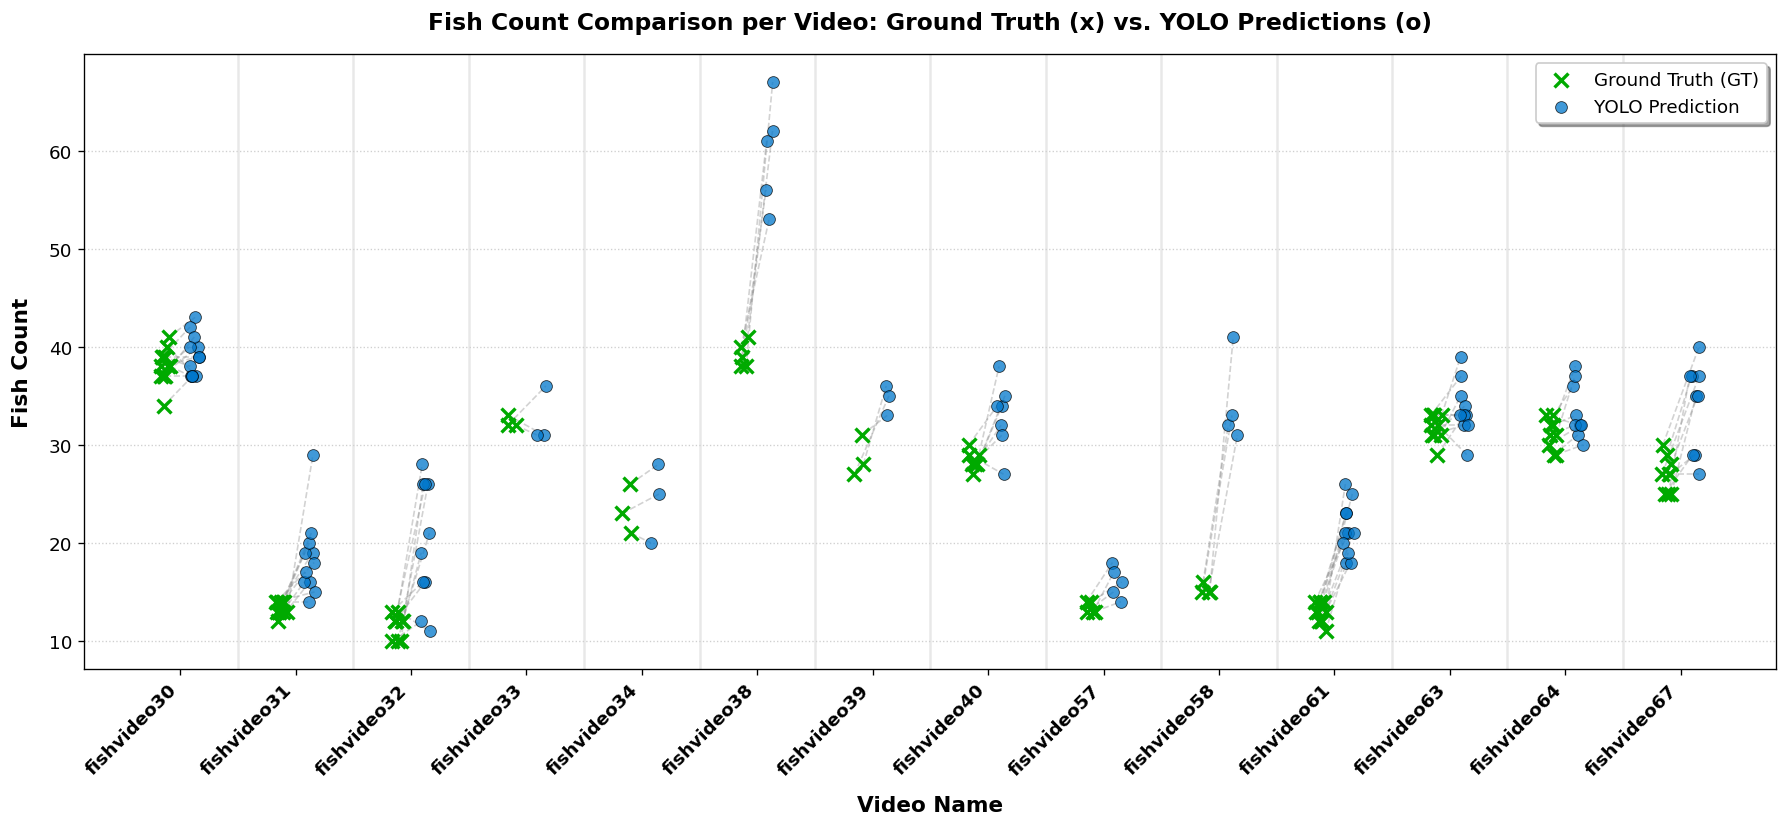

In [13]:
# ==============================================================================
# PLOT: FISH COUNT PER VIDEO (GROUND TRUTH VS. YOLO PREDICTIONS)
# ==============================================================================

# 1. Sort videos naturally by their numeric ID (e.g., fishvideo30 -> fishvideo67)
unique_videos = sorted(
    df_counts["video"].unique(),
    key=lambda v: (
        int(re.findall(r"\d+", v)[0]) if re.findall(r"\d+", v) else v
    ),
)
video_to_x = {v: i for i, v in enumerate(unique_videos)}

# 2. Setup plot dimensions
plt.figure(figsize=(15, 7), dpi=120)
np.random.seed(42)  # For reproducible jitter

# Plot paired data points for each frame
for idx, row in df_counts.iterrows():
    x_base = video_to_x[row["video"]]

    # Add slight random horizontal jitter to separate overlapping counts
    jitter_gt = np.random.uniform(-0.05, 0.05)
    jitter_pred = np.random.uniform(-0.05, 0.05)

    x_gt = x_base - 0.12 + jitter_gt
    x_pred = x_base + 0.12 + jitter_pred

    y_gt = row["gt_count"]
    y_pred = row["pred_count"]

    # Thin connector line showing count delta per frame
    plt.plot(
        [x_gt, x_pred],
        [y_gt, y_pred],
        color="gray",
        alpha=0.35,
        linestyle="--",
        linewidth=1,
    )

    # Plot GT (Green Cross)
    plt.scatter(
        x_gt,
        y_gt,
        color="#00aa00",
        marker="x",
        s=70,
        linewidths=2,
        zorder=3,
        label="Ground Truth (GT)" if idx == 0 else "",
    )

    # Plot YOLO Prediction (Blue Circle)
    plt.scatter(
        x_pred,
        y_pred,
        color="#0077cc",
        marker="o",
        s=50,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
        label="YOLO Prediction" if idx == 0 else "",
    )

# 3. Aesthetics & Axis Configuration
plt.xticks(
    ticks=range(len(unique_videos)),
    labels=unique_videos,
    rotation=45,
    ha="right",
    fontsize=11,
    fontweight="bold",
)
plt.yticks(fontsize=11)
plt.xlabel("Video Name", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Fish Count", fontsize=13, fontweight="bold", labelpad=10)
plt.title(
    "Fish Count Comparison per Video: Ground Truth (x) vs. YOLO Predictions (o)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(frameon=True, fontsize=11, loc="upper right", shadow=True)

# Add subtle vertical separators between videos
for x in range(len(unique_videos) - 1):
    plt.axvline(x=x + 0.5, color="lightgray", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()

# Further visualization code examples

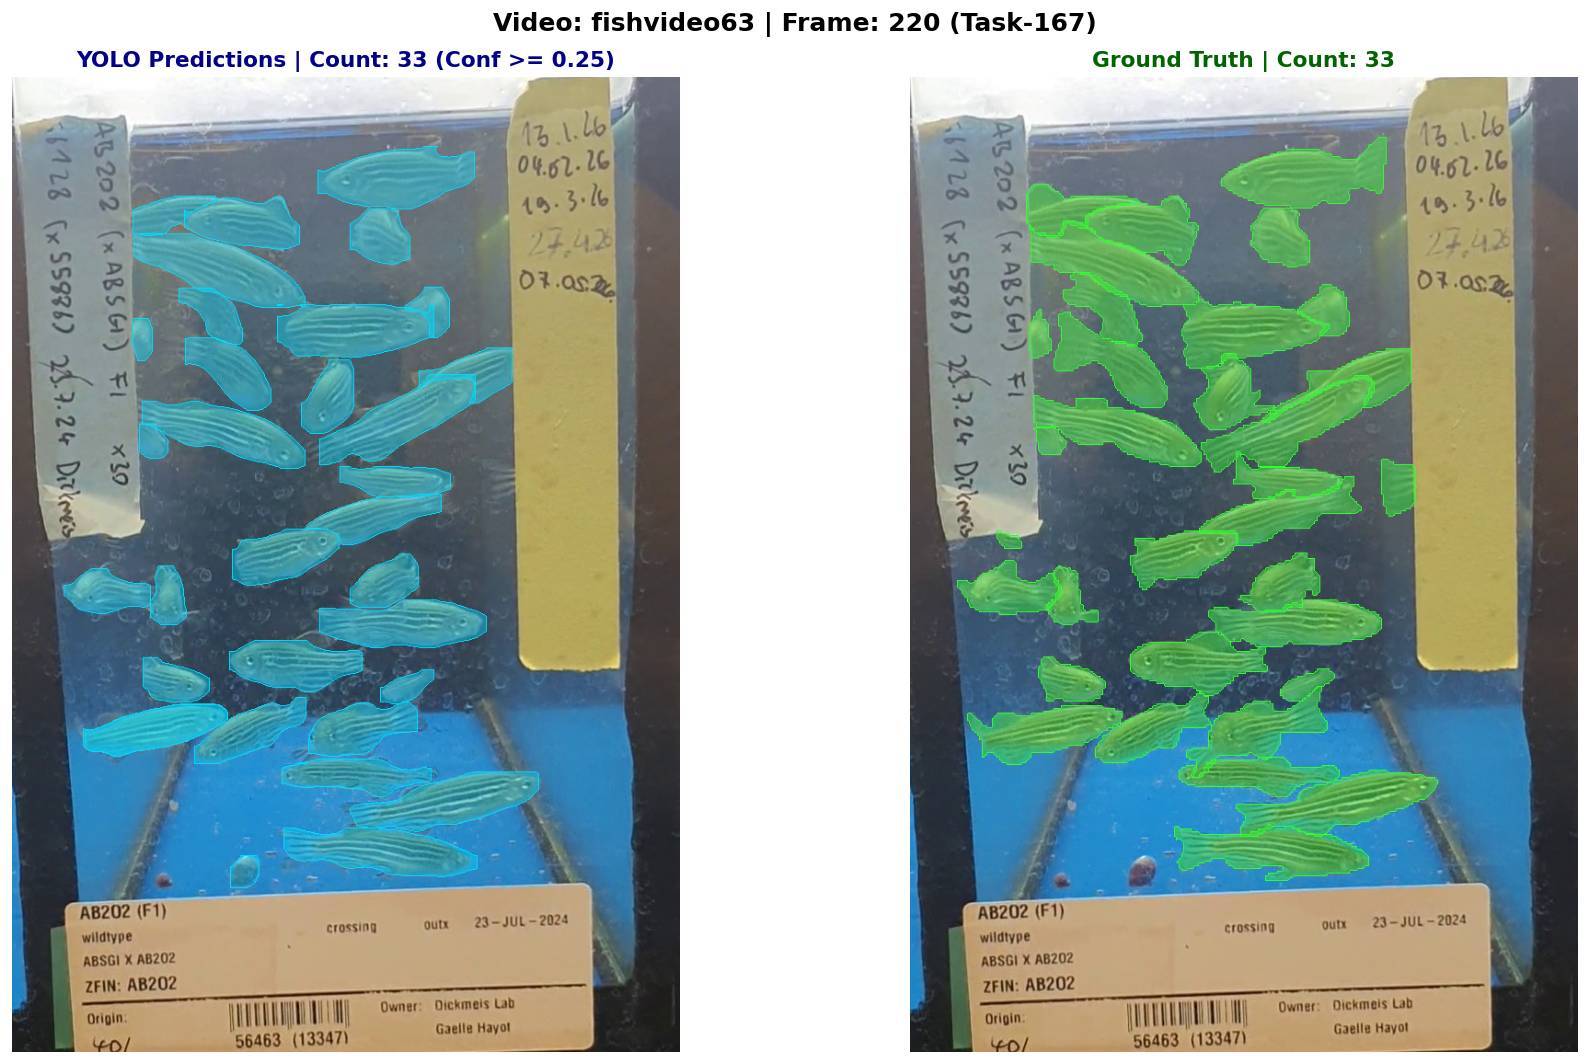

In [14]:
# ==============================================================================
# VISUALIZATION: YOLO PREDICTIONS VS. GROUND TRUTH MASKS
# ==============================================================================


def overlay_masks(
    image: np.ndarray,
    masks: List[np.ndarray],
    color: Tuple[int, int, int] = (0, 255, 0),
    alpha: float = 0.45,
) -> np.ndarray:
    """Overlays binary masks onto an RGB image with transparency and contours.

    Args:
        image (np.ndarray): Base image in RGB format (H, W, 3).
        masks (List[np.ndarray]): List of 2D binary masks (H, W).
        color (Tuple[int, int, int]): RGB color tuple for the masks.
        alpha (float): Transparency blend factor (0.0 to 1.0).

    Returns:
        np.ndarray: Blended RGB image.
    """
    overlay = image.copy()
    for mask in masks:
        if mask is None or mask.sum() == 0:
            continue
        # Apply color overlay
        overlay[mask > 0] = (
            overlay[mask > 0] * (1 - alpha) + np.array(color) * alpha
        )
        # Draw contour border for clear separation
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(overlay, contours, -1, color, 1)

    return overlay.astype(np.uint8)


def plot_comparison(
    video_name: str,
    frame_nr: int,
    conf_threshold: float = CONFIG.conf_threshold,
) -> None:
    """Loads a specific frame, runs YOLO, and visualizes YOLO vs.

    GT masks side by side.

    Args:
        video_name (str): Video prefix (e.g., 'fishvideo30').
        frame_nr (int): Frame number to display.
        conf_threshold (float): Confidence threshold for YOLO predictions.
    """
    finished_folder = CONFIG.gt_labels_dir / f"{video_name}_finished"
    txt_file = CONFIG.gt_labels_dir / f"{video_name}.txt"

    # Resolve frame image directory
    frames_folder = CONFIG.recordings_dir / f"frames_{video_name}"
    if not frames_folder.exists():
        frames_folder = CONFIG.recordings_dir / video_name

    # Check existence
    if not txt_file.exists() or not finished_folder.exists():
        logger.error(
            f"Ground truth files for '{video_name}' not found in {CONFIG.gt_labels_dir}"
        )
        return

    # 1. Resolve Task-ID corresponding to the given frame_nr
    with open(txt_file, "r", encoding="utf-8") as f:
        frame_numbers = [int(num) for num in re.findall(r"\d+", f.read())]

    if frame_nr not in frame_numbers:
        logger.error(
            f"Frame {frame_nr} is not mapped in {txt_file.name}. Available frames: {frame_numbers}"
        )
        return

    frame_index = frame_numbers.index(frame_nr)

    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = categorize_mask_files(all_mask_files)
    sorted_task_ids = sorted(task_groups.keys())

    if frame_index >= len(sorted_task_ids):
        logger.error(
            f"No matching task found for index {frame_index} in {finished_folder}."
        )
        return

    task_id = sorted_task_ids[frame_index]

    # 2. Load and crop frame
    img_path = frames_folder / f"{frame_nr:04d}.jpg"
    if not img_path.exists():
        img_path = frames_folder / f"{frame_nr}.jpg"
    if not img_path.exists():
        logger.error(f"Image for frame {frame_nr} not found in {frames_folder}")
        return

    img_bgr = cv2.imread(str(img_path))
    h_orig, w_orig = img_bgr.shape[:2]

    x1, y1, x2, y2 = load_crop_box(
        finished_folder, video_name, frame_nr, task_id, img_bgr.shape
    )
    img_crop_bgr = img_bgr[y1:y2, x1:x2]
    img_crop_rgb = cv2.cvtColor(img_crop_bgr, cv2.COLOR_BGR2RGB)
    h_crop, w_crop = img_crop_rgb.shape[:2]

    # 3. Load GT fish masks
    gt_masks = []
    for mf in task_groups[task_id]["fish"]:
        m = load_cropped_mask(
            mask_path=mf,
            crop_coords=(x1, y1, x2, y2),
            orig_shape=(h_orig, w_orig),
        )
        if m is not None:
            gt_masks.append(m)

    # 4. Predict with YOLO
    results = model.predict(
        source=img_crop_bgr,
        conf=conf_threshold,
        retina_masks=True,
        verbose=False,
        device=CONFIG.device,
    )

    pred_masks = []
    if results[0].masks is not None:
        raw_masks = results[0].masks.data.cpu().numpy()
        for rm in raw_masks:
            rm = (rm > 0.5).astype(np.uint8)
            if rm.shape[:2] != (h_crop, w_crop):
                rm = cv2.resize(
                    rm, (w_crop, h_crop), interpolation=cv2.INTER_NEAREST
                )
            pred_masks.append(rm)

    # 5. Create overlays
    yolo_overlay = overlay_masks(
        img_crop_rgb, pred_masks, color=(0, 220, 255), alpha=0.4
    )  # Cyan/Yellow
    gt_overlay = overlay_masks(
        img_crop_rgb, gt_masks, color=(50, 255, 50), alpha=0.4
    )  # Green

    # 6. Plotting side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 9), dpi=120)

    # Left: YOLO Predictions
    axes[0].imshow(yolo_overlay)
    axes[0].set_title(
        f"YOLO Predictions | Count: {len(pred_masks)} (Conf >= {conf_threshold})",
        fontsize=13,
        fontweight="bold",
        color="darkblue",
    )
    axes[0].axis("off")

    # Right: Ground Truth
    axes[1].imshow(gt_overlay)
    axes[1].set_title(
        f"Ground Truth | Count: {len(gt_masks)}",
        fontsize=13,
        fontweight="bold",
        color="darkgreen",
    )
    axes[1].axis("off")

    plt.suptitle(
        f"Video: {video_name} | Frame: {frame_nr} (Task-{task_id})",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


# ==============================================================================
# RUN EXAMPLE
# ==============================================================================
plot_comparison(video_name="fishvideo63", frame_nr=220)